In [1]:
import tensorflow as tf 
print("tensorflow version se ",tf.__version__)

tensorflow version se  2.21.0


In [2]:
mnist=tf.keras.datasets.mnist

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [4]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


In [5]:
x_train[5998]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 105, 253,  65,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 148, 224,  14,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 150, 245, 159,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 211, 253,  63,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [6]:
x_train[0][1]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=uint8)

In [7]:
import sys
print(sys.executable)

c:\Users\Jagdish singh\jupyter311\Scripts\python.exe


In [8]:
import matplotlib.pyplot as plt


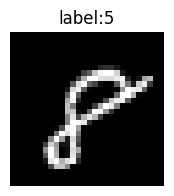

In [9]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[59999], cmap='gray')   # gray is standard spelling
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

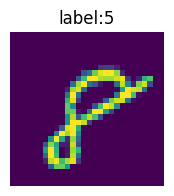

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # gray without it  heatmap
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

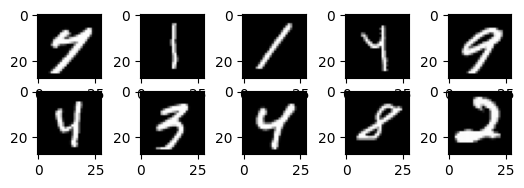

In [11]:
for i in range(1,11):
    plt.subplot(5,5,i)
    plt.imshow(x_train[i+1000],cmap='grey')
    
plt.show()

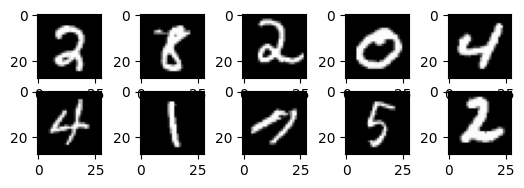

In [12]:
import random
import numpy as np

for i in range(1,11):
    plt.subplot(5,5,i)
    index=np.random.randint(0,59999)
    plt.imshow(x_train[index],cmap='grey')
    
plt.show()
# using np.random.randit to genrte random numbers for visualization


In [13]:
x_train=x_train/255.0
x_test=x_test/255.0

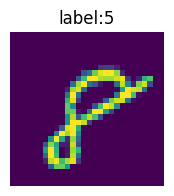

In [14]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[59999])   # after scaling/normlizing data the image quality effects
plt.axis('off')   
plt.title("label:{}".format(y_train[0]))
plt.show()

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras import Input

In [16]:
# Sequential: Container to build neural network layer-by-layer in a linear stack.
# Input: Defines the shape/size of data entering the model.
# Flatten: Converts multi-dimensional input (e.g., 28x28 image) into a 1D vector.
# Dense: Fully connected layer where neurons learn patterns using weights and activation functions.

In [17]:
model=Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [18]:
'''A Dense layer is a type of layer where:
every neuron connects to all neurons in the previous layer
(fully connected layer).

#  hidden layer is any layer between input and output of a neural network.'''

'A Dense layer is a type of layer where:\nevery neuron connects to all neurons in the previous layer\n(fully connected layer).\n\n#  hidden layer is any layer between input and output of a neural network.'

In [19]:
# Binary Classification: sigmoid  //same like log regression
# Multi-class Classification: softmax  //same like mutlinomail log regresion
# Regression: linear

##  Each layer has a different job, so it needs a different activation behavior.

In [20]:
#  compiling fit the engine optimize it and reduce fuel loss
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=['accuracy'])


In [21]:
# model is tested on validation after each epochs 
# validation_data is used to evaluate model performance on unseen data after each epoch without updating weights, helping detect overfitting and monitor generalization ability.

In [22]:
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10)

Epoch 1/10


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9340 - loss: 0.2243 - val_accuracy: 0.9570 - val_loss: 0.1418
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9700 - loss: 0.0975 - val_accuracy: 0.9661 - val_loss: 0.1042
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9786 - loss: 0.0670 - val_accuracy: 0.9744 - val_loss: 0.0824
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9833 - loss: 0.0509 - val_accuracy: 0.9748 - val_loss: 0.0829
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9865 - loss: 0.0413 - val_accuracy: 0.9770 - val_loss: 0.0847
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9890 - loss: 0.0335 - val_accuracy: 0.9747 - val_loss: 0.0851
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9902 - loss: 0.0286 - val_accuracy: 0.9748 - val_loss: 0.0973
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9923 - loss: 0.0234 - val_accurac

In [23]:
# r is object returned by model ..it is called as history object 
# r stores all training results during training..

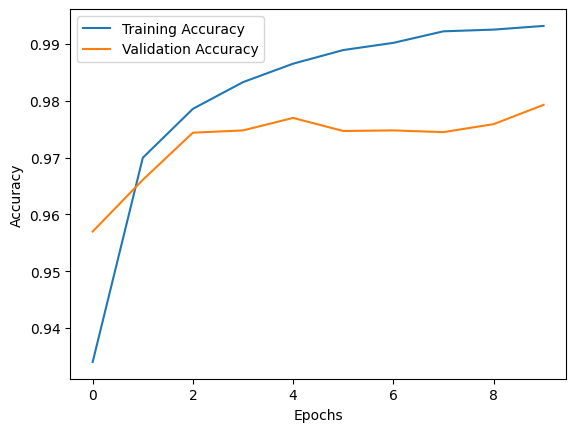

In [24]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [25]:
# Both training and validation accuracy increase together and remain close, indicating good learning and proper generalization.”

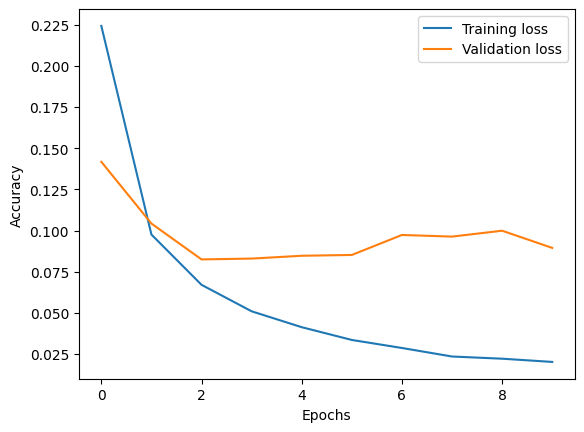

In [26]:
plt.plot(r.history['loss'], label='Training loss ')
plt.plot(r.history['val_loss'], label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [27]:
x_test.shape   # for test You have 10,000 grayscale images, each of size 28×28 pixels.

(10000, 28, 28)

In [28]:
model.predict(x_test).shape # 10 is no. of output neurons and is equal to number of classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [29]:
model.predict(x_test)[0] # model predict 10 classes for each image btw 0-9

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([6.3828724e-16, 2.4180652e-10, 1.6183210e-13, 2.6961883e-10,
       2.5889306e-14, 1.4542584e-16, 1.2093746e-19, 1.0000000e+00,
       3.3236044e-15, 9.6151433e-09], dtype=float32)

In [30]:
import numpy as np
y_pred = model.predict(x_test).argmax(axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [31]:
!py -m pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 970,    1,    1,    0,    2,    1,    3,    1,    1,    0],
       [   0, 1128,    0,    1,    0,    0,    2,    1,    3,    0],
       [   2,    0, 1006,    6,    1,    0,    5,   10,    2,    0],
       [   0,    0,    2,  994,    0,    1,    0,    8,    3,    2],
       [   1,    0,    0,    0,  965,    0,    4,    3,    0,    9],
       [   2,    0,    0,   10,    0,  867,    2,    2,    6,    3],
       [   3,    2,    0,    1,    7,    9,  933,    0,    3,    0],
       [   1,    1,    5,    1,    2,    0,    0, 1015,    2,    1],
       [   4,    1,    3,    8,    5,    2,    1,    5,  943,    2],
       [   3,    4,    0,    3,   14,    2,    0,    9,    2,  972]])

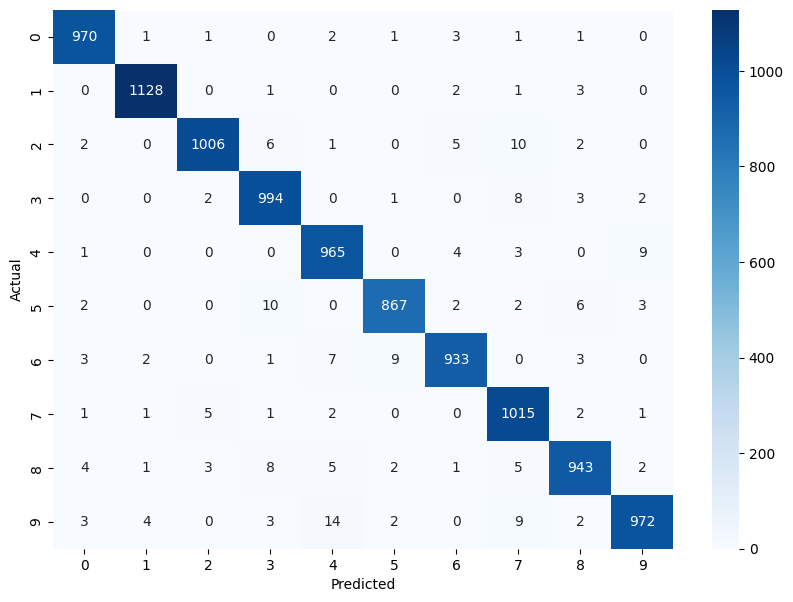

In [33]:
plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
np.where(y_test != y_pred)  # provide the indexes np.where

(array([ 115,  149,  151,  247,  264,  321,  340,  381,  495,  582,  619,
         646,  720,  760,  882, 1014, 1039, 1044, 1112, 1182, 1192, 1226,
        1232, 1242, 1247, 1292, 1299, 1319, 1337, 1349, 1393, 1395, 1414,
        1425, 1429, 1522, 1530, 1549, 1554, 1569, 1601, 1609, 1642, 1681,
        1709, 1721, 1737, 1790, 1853, 1878, 1901, 2001, 2004, 2018, 2033,
        2044, 2093, 2109, 2118, 2130, 2135, 2189, 2272, 2291, 2293, 2326,
        2387, 2422, 2447, 2454, 2488, 2526, 2597, 2598, 2648, 2654, 2721,
        2730, 2770, 2860, 2896, 2915, 2921, 2927, 2930, 2939, 2953, 2979,
        2995, 3023, 3060, 3115, 3117, 3206, 3225, 3261, 3289, 3337, 3369,
        3405, 3422, 3460, 3475, 3503, 3520, 3558, 3597, 3629, 3681, 3727,
        3762, 3776, 3780, 3818, 3850, 3893, 3906, 3976, 3985, 4007, 4065,
        4075, 4093, 4163, 4176, 4248, 4289, 4294, 4306, 4314, 4360, 4425,
        4497, 4504, 4536, 4547, 4567, 4571, 4601, 4731, 4761, 4807, 4814,
        4823, 4838, 4880, 5331, 5457, 

In [ ]:
len(np.where(y_test != y_pred)[0]) # no of wrong predictions

207

In [36]:
(270/10000) * 100 
100 - 2.7

97.3

In [37]:
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices

array([ 115,  149,  151,  247,  264,  321,  340,  381,  495,  582,  619,
        646,  720,  760,  882, 1014, 1039, 1044, 1112, 1182, 1192, 1226,
       1232, 1242, 1247, 1292, 1299, 1319, 1337, 1349, 1393, 1395, 1414,
       1425, 1429, 1522, 1530, 1549, 1554, 1569, 1601, 1609, 1642, 1681,
       1709, 1721, 1737, 1790, 1853, 1878, 1901, 2001, 2004, 2018, 2033,
       2044, 2093, 2109, 2118, 2130, 2135, 2189, 2272, 2291, 2293, 2326,
       2387, 2422, 2447, 2454, 2488, 2526, 2597, 2598, 2648, 2654, 2721,
       2730, 2770, 2860, 2896, 2915, 2921, 2927, 2930, 2939, 2953, 2979,
       2995, 3023, 3060, 3115, 3117, 3206, 3225, 3261, 3289, 3337, 3369,
       3405, 3422, 3460, 3475, 3503, 3520, 3558, 3597, 3629, 3681, 3727,
       3762, 3776, 3780, 3818, 3850, 3893, 3906, 3976, 3985, 4007, 4065,
       4075, 4093, 4163, 4176, 4248, 4289, 4294, 4306, 4314, 4360, 4425,
       4497, 4504, 4536, 4547, 4567, 4571, 4601, 4731, 4761, 4807, 4814,
       4823, 4838, 4880, 5331, 5457, 5634, 5642, 56

In [38]:
print(f'Total misclassified images: {len(misclassified_indices)}')


Total misclassified images: 207


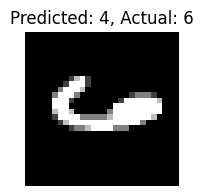

In [ ]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')  #inshow for image plotiing
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

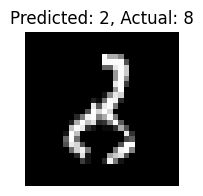

In [40]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

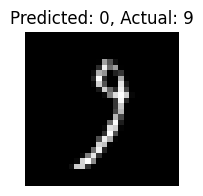

In [41]:

i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

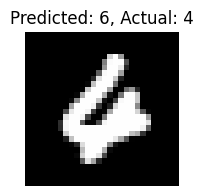

In [42]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

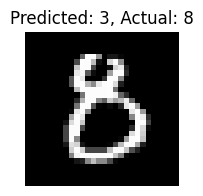

In [43]:
i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()